## **Détection d'Équipements de Protection Individuelle**

**Auteurs :** Maram NASR et Skander HAJ MABROUK

**0.Installations et Imports**

In [1]:
!pip install -q torch torchvision
!pip install -q pycocotools

import torch
import torchvision
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import defaultdict
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import box_iou
import torchvision.transforms.functional as F

**1.Configuration**

In [9]:
from google.colab import drive
drive.mount('/content/drive')

CLASSES     = ["__background__", "casque", "gilet", "gants", "goggles", "boots", "masque"]
NUM_CLASSES = len(CLASSES)
CLASS2IDX   = {cls: idx for idx, cls in enumerate(CLASSES)}
IDX2CLASS   = {idx: cls for cls, idx in CLASS2IDX.items()}

CLASS_ALIASES = {
    "casque": "casque", "helmet" : "casque",
    "gilet" : "gilet",  "vest"   : "gilet",
    "gants" : "gants",  "gloves" : "gants",
    "goggles": "goggles", "googles": "goggles", "lunettes": "goggles",
    "boots" : "boots",  "bottes" : "boots",
    "masque": "masque", "mask"   : "masque",
}

ROOT            = "/content/drive/MyDrive/ObjectDetectionDataset"
TEST_DIR        = os.path.join(ROOT, "test")
TEST_CSV        = os.path.join(TEST_DIR, "_annotations.csv")
BEST_MODEL_PATH = os.path.join(ROOT, "best_model_finetuned.pth")
SCORE_THRESH    = 0.2
IOU_THRESH      = 0.5

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2.Chargement annotations test**

In [4]:
def load_csv(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = [c.strip().lower() for c in df.columns]
    annotations = {}

    for _, row in df.iterrows():
        filename = str(row["filename"]).strip()
        label    = str(row["class"]).strip().lower()
        label    = CLASS_ALIASES.get(label, label)
        x1, y1   = float(row["xmin"]), float(row["ymin"])
        x2, y2   = float(row["xmax"]), float(row["ymax"])

        if x2 <= x1 or y2 <= y1:
            continue
        if label not in CLASS2IDX:
            continue

        annotations.setdefault(filename, []).append({
            "label": label,
            "bbox" : [x1, y1, x2, y2]
        })
    return annotations


test_anns = load_csv(TEST_CSV)
print(f"Test : {len(test_anns)} images chargées")

from collections import Counter
labels_test = [ann["label"] for anns in test_anns.values() for ann in anns]
print("\nDistribution des classes (test) :")
for cls, count in Counter(labels_test).most_common():
    print(f"  {cls:<12} : {count} boîtes")

Test : 27 images chargées

Distribution des classes (test) :
  boots        : 10 boîtes
  gants        : 6 boîtes
  casque       : 5 boîtes
  masque       : 4 boîtes
  goggles      : 3 boîtes
  gilet        : 2 boîtes


**3.Chargement du modèle**

In [6]:
def build_model(num_classes):
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    model   = fasterrcnn_resnet50_fpn_v2(weights=weights)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


model = build_model(NUM_CLASSES).to(device)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

**4.Calcul mAP@0.5 par classe**

In [10]:
def compute_map(model, test_anns, test_dir, device,
                iou_thresh=IOU_THRESH, score_thresh=SCORE_THRESH):

    stats = {
        cls: {"scores": [], "tp": [], "n_gt": 0}
        for cls in CLASSES[1:]
    }

    for filename, gt_list in test_anns.items():
        img_path = os.path.join(test_dir, filename)
        if not os.path.exists(img_path):
            continue

        # Inférence
        img_t = F.to_tensor(Image.open(img_path).convert("RGB")).to(device)
        with torch.no_grad():
            pred = model([img_t])[0]

        keep        = pred["scores"] >= score_thresh
        pred_boxes  = pred["boxes"][keep].cpu()
        pred_labels = pred["labels"][keep].cpu()
        pred_scores = pred["scores"][keep].cpu()

        # Ground truth
        gt_boxes  = torch.tensor([a["bbox"]  for a in gt_list], dtype=torch.float32)
        gt_labels = torch.tensor([CLASS2IDX[a["label"]] for a in gt_list], dtype=torch.int64)

        for cls_idx, cls_name in enumerate(CLASSES[1:], start=1):
            gt_mask   = gt_labels == cls_idx
            pred_mask = pred_labels == cls_idx

            gt_b  = gt_boxes[gt_mask]
            pr_b  = pred_boxes[pred_mask]
            pr_s  = pred_scores[pred_mask]

            stats[cls_name]["n_gt"] += len(gt_b)

            if len(pr_b) == 0:
                continue

            order   = torch.argsort(pr_s, descending=True)
            pr_b    = pr_b[order]
            pr_s    = pr_s[order]
            matched = torch.zeros(len(gt_b), dtype=torch.bool)

            for i in range(len(pr_b)):
                stats[cls_name]["scores"].append(float(pr_s[i]))
                if len(gt_b) > 0:
                    ious = box_iou(pr_b[i].unsqueeze(0), gt_b)[0]
                    best = ious.argmax()
                    if ious[best] >= iou_thresh and not matched[best]:
                        stats[cls_name]["tp"].append(1)
                        matched[best] = True
                    else:
                        stats[cls_name]["tp"].append(0)
                else:
                    stats[cls_name]["tp"].append(0)

    # Calculer AP par classe
    aps = {}
    for cls_name, s in stats.items():
        if s["n_gt"] == 0:
            continue
        if len(s["scores"]) == 0:
            aps[cls_name] = 0.0
            continue

        scores = np.array(s["scores"])
        tp     = np.array(s["tp"])
        order  = np.argsort(-scores)
        tp     = tp[order]

        cum_tp    = np.cumsum(tp)
        cum_fp    = np.cumsum(1 - tp)
        precision = cum_tp / (cum_tp + cum_fp + 1e-8)
        recall    = cum_tp / (s["n_gt"] + 1e-8)

        recall    = np.concatenate([[0], recall,    [1]])
        precision = np.concatenate([[0], precision, [0]])
        for i in range(len(precision) - 2, -1, -1):
            precision[i] = max(precision[i], precision[i+1])

        aps[cls_name] = float(np.trapz(precision, recall))

    mAP = float(np.mean(list(aps.values())))
    return aps, mAP


aps, mAP = compute_map(model, test_anns, TEST_DIR, device)

# tableau
print(f"  {'Classe':<12}  {'AP@0.5':>10}  {'n GT':>6}")
labels_test_counter = Counter(labels_test)
for cls_name, ap in aps.items():
    n = labels_test_counter.get(cls_name, 0)
    print(f"  {cls_name:<12}  {ap:>10.4f}  {n:>6}")
print(f"  {'mAP@0.5':<12}  {mAP:>10.4f}")

  Classe            AP@0.5    n GT
  casque            0.0000       5
  gilet             0.5000       2
  gants             0.6111       6
  goggles           0.0000       3
  boots             0.6355      10
  masque            0.3611       4
  mAP@0.5           0.3513


/tmp/ipykernel_4705/3249557874.py:83: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aps[cls_name] = float(np.trapz(precision, recall))


**5.Graphe AP par classe**

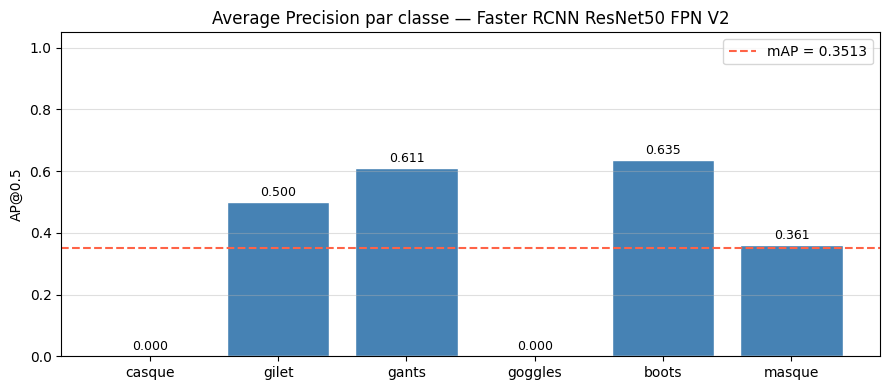

In [11]:
cls_names = list(aps.keys())
ap_values = [aps[c] for c in cls_names]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cls_names, ap_values, color="steelblue", edgecolor="white")
ax.axhline(mAP, color="tomato", linestyle="--", linewidth=1.5, label=f"mAP = {mAP:.4f}")

for bar, val in zip(bars, ap_values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylim(0, 1.05)
ax.set_ylabel("AP@0.5")
ax.set_title("Average Precision par classe — Faster RCNN ResNet50 FPN V2")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "ap_par_classe.png"), dpi=150)
plt.show()

**6. Résultats qualitatifs(succès)**

In [12]:
def draw_pred_and_gt(img_path, gt_list, model, device,
                     score_thresh=SCORE_THRESH, ax=None, title=""):
    img_np = np.array(Image.open(img_path).convert("RGB"))
    img_t  = F.to_tensor(Image.open(img_path).convert("RGB")).to(device)
    colors = plt.cm.get_cmap("tab10", NUM_CLASSES)

    with torch.no_grad():
        pred = model([img_t])[0]

    keep        = pred["scores"] >= score_thresh
    pred_boxes  = pred["boxes"][keep].cpu().numpy()
    pred_labels = pred["labels"][keep].cpu().numpy()
    pred_scores = pred["scores"][keep].cpu().numpy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    ax.imshow(img_np)

    # Ground truth — vert tirets
    for ann in gt_list:
        x1, y1, x2, y2 = ann["bbox"]
        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
            linewidth=2, edgecolor="lime", facecolor="none", linestyle="--")
        ax.add_patch(rect)
        ax.text(x1, y1-6, ann["label"], color="lime", fontsize=7,
                bbox=dict(facecolor="black", alpha=0.4, pad=1, edgecolor="none"))

    # Prédictions — couleur pleine
    for box, lbl, score in zip(pred_boxes, pred_labels, pred_scores):
        x1, y1, x2, y2 = box
        color = colors(int(lbl))
        rect  = patches.Rectangle((x1,y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y2+10, f"{IDX2CLASS[int(lbl)]} {score:.2f}",
                color=color, fontsize=7,
                bbox=dict(facecolor="white", alpha=0.5, pad=1, edgecolor="none"))

    ax.set_title(title, fontsize=9)
    ax.axis("off")

/tmp/ipykernel_4705/3863804153.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", NUM_CLASSES)


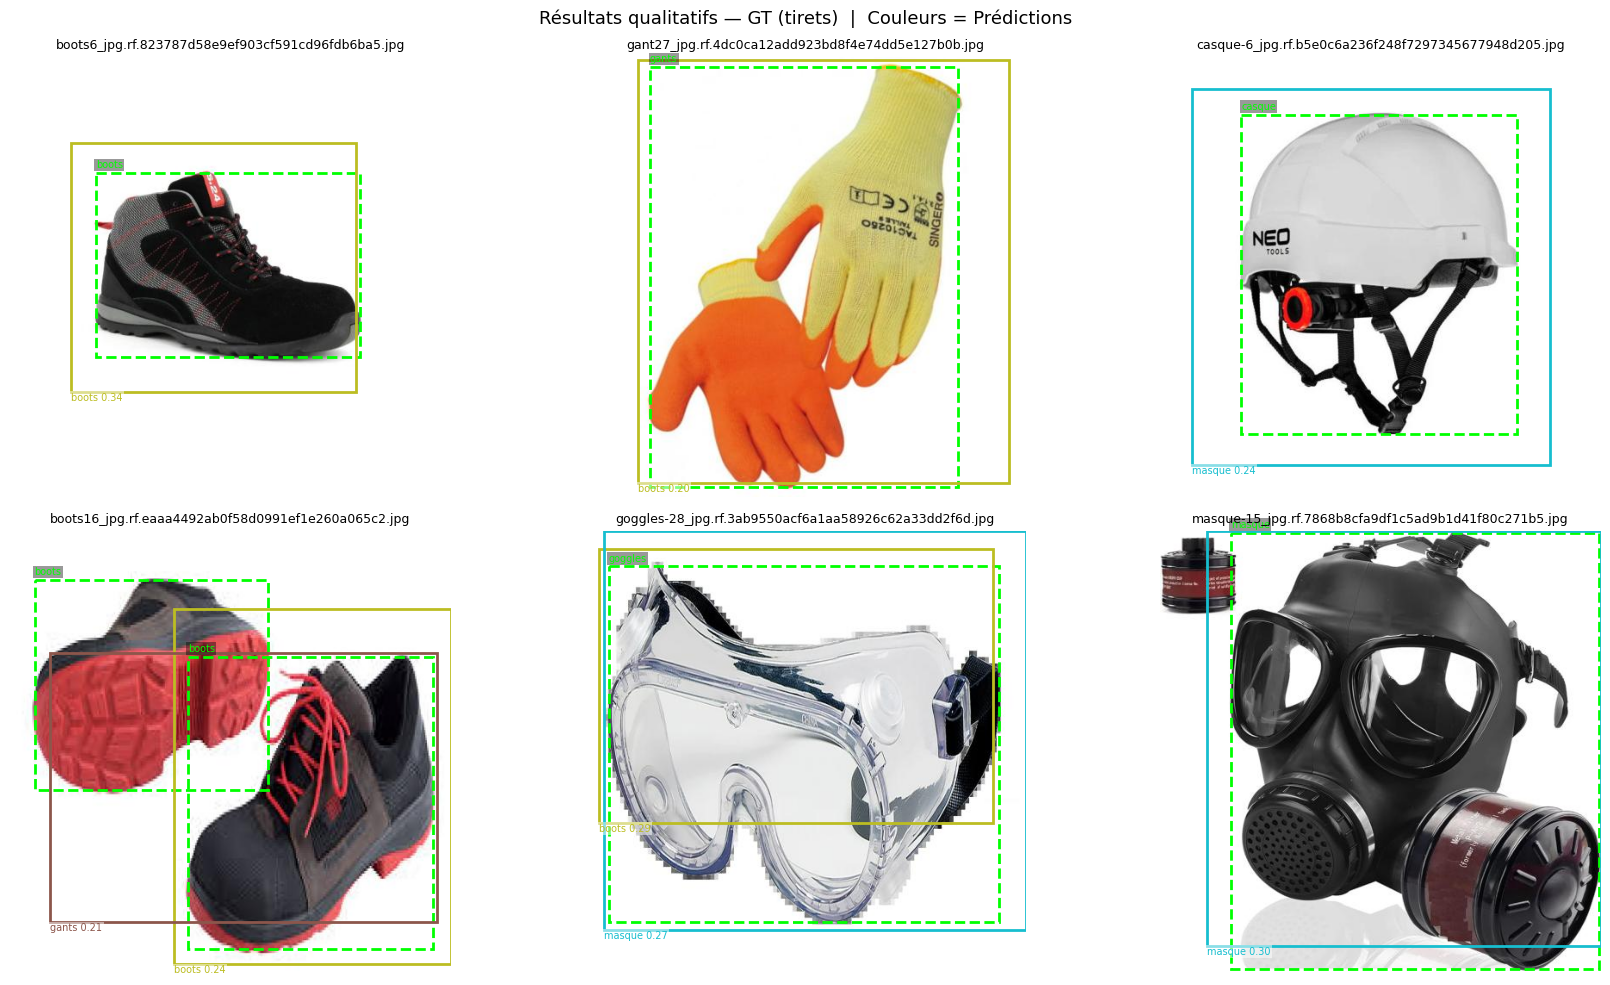

In [13]:
# Afficher 6 images aléatoires du test
sample_files = random.sample(list(test_anns.keys()), min(6, len(test_anns)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, filename in zip(axes, sample_files):
    img_path = os.path.join(TEST_DIR, filename)
    draw_pred_and_gt(img_path, test_anns[filename], model, device,
                     ax=ax, title=filename)

fig.suptitle("Résultats qualitatifs — GT (tirets)  |  Couleurs = Prédictions",
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "qualitative_success.png"), dpi=150)
plt.show()

**7.Erreurs communes (cas difficiles)**

/tmp/ipykernel_4705/3863804153.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", NUM_CLASSES)


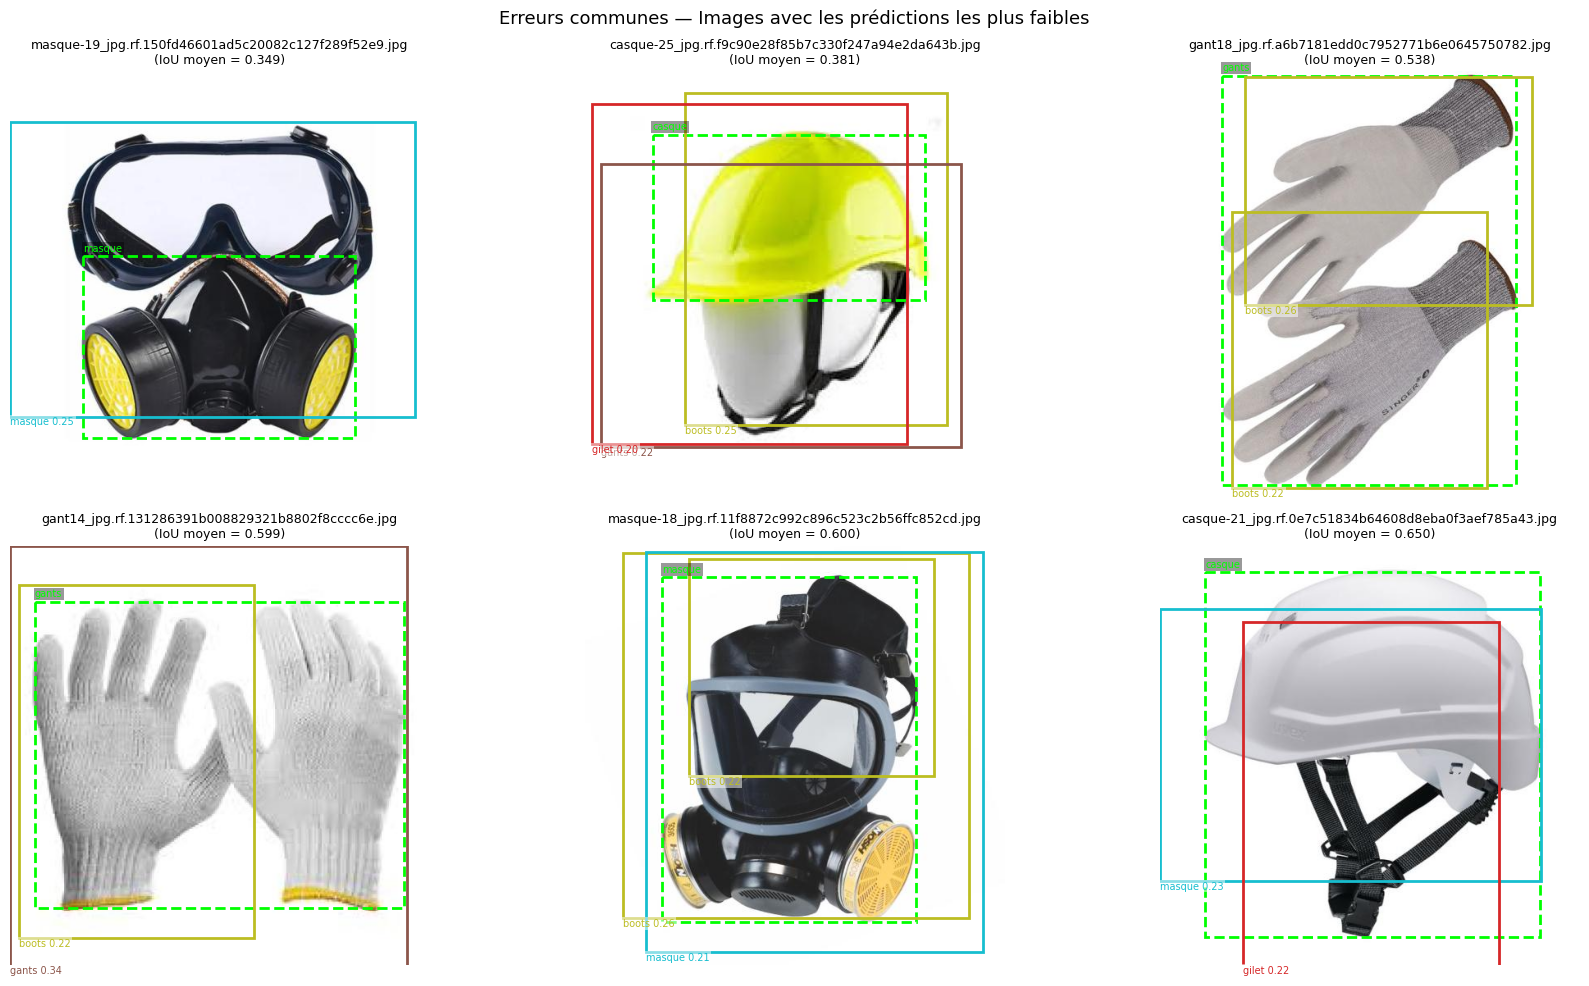

In [14]:
def get_mean_iou(filename, gt_list, model, device, score_thresh=SCORE_THRESH):
    """Retourne l'IoU moyen entre GT et prédictions pour une image."""
    img_t = F.to_tensor(Image.open(
        os.path.join(TEST_DIR, filename)).convert("RGB")).to(device)

    with torch.no_grad():
        pred = model([img_t])[0]

    keep      = pred["scores"] >= score_thresh
    pr_boxes  = pred["boxes"][keep].cpu()
    gt_boxes  = torch.tensor([a["bbox"] for a in gt_list], dtype=torch.float32)

    if len(pr_boxes) == 0 or len(gt_boxes) == 0:
        return 0.0

    iou = box_iou(pr_boxes, gt_boxes)
    return float(iou.max(dim=1).values.mean())


# Calculer l'IoU moyen pour toutes les images test
iou_scores = []
for filename, gt_list in test_anns.items():
    img_path = os.path.join(TEST_DIR, filename)
    if not os.path.exists(img_path):
        continue
    score = get_mean_iou(filename, gt_list, model, device)
    iou_scores.append((score, filename, gt_list))

# Trier par IoU croissant → les pires en premier
iou_scores.sort(key=lambda x: x[0])
worst_cases = iou_scores[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (iou, filename, gt_list) in zip(axes, worst_cases):
    img_path = os.path.join(TEST_DIR, filename)
    draw_pred_and_gt(img_path, gt_list, model, device,
                     ax=ax, title=f"{filename}\n(IoU moyen = {iou:.3f})")

fig.suptitle("Erreurs communes — Images avec les prédictions les plus faibles",
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "qualitative_errors.png"), dpi=150)
plt.show()

**8.Courbe Précision-Rappel par classe**

In [18]:
cache = {}  # { filename: (pred_boxes, pred_labels, pred_scores) }

for filename in test_anns.keys():
    img_path = os.path.join(TEST_DIR, filename)
    if not os.path.exists(img_path):
        continue

    img_t = F.to_tensor(Image.open(img_path).convert("RGB")).to(device)
    with torch.no_grad():
        pred = model([img_t])[0]

    keep = pred["scores"] >= 0.1
    cache[filename] = (
        pred["boxes"][keep].cpu(),
        pred["labels"][keep].cpu(),
        pred["scores"][keep].cpu()
    )

pr_curves = {}

for cls_name in CLASSES[1:]:
    s       = {"scores": [], "tp": [], "n_gt": 0}
    cls_idx = CLASS2IDX[cls_name]

    for filename, gt_list in test_anns.items():
        if filename not in cache:
            continue

        pred_boxes, pred_labels, pred_scores = cache[filename]

        gt_boxes = torch.tensor(
            [a["bbox"] for a in gt_list if CLASS2IDX[a["label"]] == cls_idx],
            dtype=torch.float32
        )
        pr_mask = pred_labels == cls_idx
        pr_b    = pred_boxes[pr_mask]
        pr_s    = pred_scores[pr_mask]

        s["n_gt"] += len(gt_boxes)
        if len(pr_b) == 0:
            continue

        order   = torch.argsort(pr_s, descending=True)
        pr_b    = pr_b[order]
        pr_s    = pr_s[order]
        matched = torch.zeros(len(gt_boxes), dtype=torch.bool)

        for j in range(len(pr_b)):
            s["scores"].append(float(pr_s[j]))
            if len(gt_boxes) > 0:
                ious = box_iou(pr_b[j].unsqueeze(0), gt_boxes)[0]
                best = ious.argmax()
                if ious[best] >= IOU_THRESH and not matched[best]:
                    s["tp"].append(1)
                    matched[best] = True
                else:
                    s["tp"].append(0)
            else:
                s["tp"].append(0)

    if s["n_gt"] == 0 or len(s["scores"]) == 0:
        pr_curves[cls_name] = (np.array([0, 1]), np.array([1, 0]))
        continue

    scores = np.array(s["scores"])
    tp     = np.array(s["tp"])
    order  = np.argsort(-scores)
    tp     = tp[order]

    cum_tp    = np.cumsum(tp)
    cum_fp    = np.cumsum(1 - tp)
    precision = cum_tp / (cum_tp + cum_fp + 1e-8)
    recall    = cum_tp / (s["n_gt"] + 1e-8)

    pr_curves[cls_name] = (recall, precision)

/tmp/ipykernel_4705/3373680269.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_pr = plt.cm.get_cmap("tab10", NUM_CLASSES)


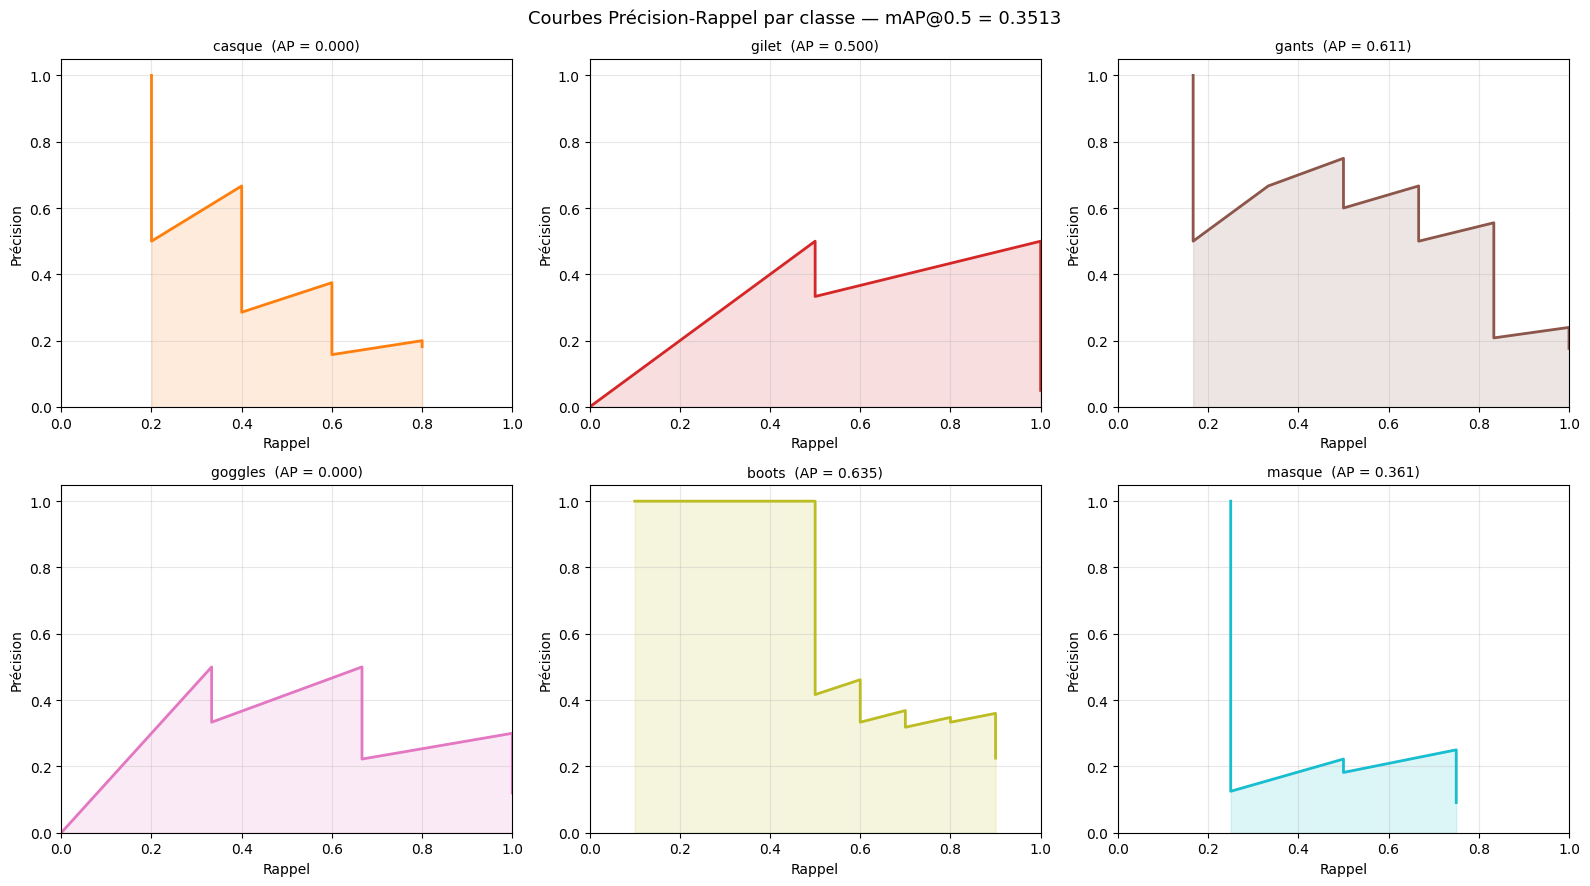

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes      = axes.flatten()
colors_pr = plt.cm.get_cmap("tab10", NUM_CLASSES)

for i, cls_name in enumerate(CLASSES[1:]):
    ax                = axes[i]
    recall, precision = pr_curves[cls_name]
    ap                = aps.get(cls_name, 0.0)
    color             = colors_pr(i + 1)

    ax.plot(recall, precision, color=color, linewidth=2)
    ax.fill_between(recall, precision, alpha=0.15, color=color)
    ax.set_title(f"{cls_name}  (AP = {ap:.3f})", fontsize=10)
    ax.set_xlabel("Rappel")
    ax.set_ylabel("Précision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

plt.suptitle(f"Courbes Précision-Rappel par classe — mAP@0.5 = {mAP:.4f}", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "precision_recall_curves.png"), dpi=150)
plt.show()

**Conclusion**

Le modèle Faster RCNN ResNet50 FPN V2 fine-tuné atteint un **mAP@0.5 de 0.3513**
sur le set de test (27 images, 6 classes PPE). Ce résultat est cohérent avec les
conditions de l'expérience : un dataset de petite taille (124 images d'entraînement)
et une grande variabilité visuelle entre les classes.

Les classes les mieux détectées sont les boots (AP=0.635) et les gants (AP=0.611),
qui bénéficient à la fois du plus grand nombre d'exemples en entraînement
(27 et 23 boîtes respectivement) et d'une apparence visuelle distinctive et
relativement homogène. Le gilet obtient un AP de 0.500, acceptable compte tenu
de seulement 2 exemples dans le set de test. En revanche, le casque et les goggles
obtiennent un AP nul, et le masque reste modeste à 0.361.

**Analyse des échecs — Casque (AP = 0.000)**

L'analyse des images d'erreur révèle deux problèmes distincts pour le casque.
Premièrement, le modèle confond systématiquement le casque avec d'autres classes :
sur casque-25 (casque jaune avec visière), il prédit "boots" et "gilet" ; sur
casque-21 (casque blanc), il prédit "masque" et "gilet". Deuxièmement, le casque
est la classe la moins représentée en entraînement (17 boîtes), ce qui limite
fortement la capacité de généralisation. La variabilité visuelle élevée —
couleurs différentes, présence ou absence de visière, orientations variées —
aggrave ce problème avec si peu d'exemples.

**Analyse des échecs — Goggles (AP = 0.000)**

Les goggles sont uniquement présents dans 3 images du set de test, ce qui rend
l'évaluation statistiquement peu fiable. De plus, les goggles apparaissent
fréquemment en co-occurrence avec d'autres EPI (notamment le masque), comme
visible sur masque-19 où le modèle détecte correctement le masque mais ignore
complètement les goggles portés simultanément. Cette superposition visuelle
crée une ambiguïté que le modèle, faute d'exemples suffisants, ne parvient pas
à résoudre.

**Biais vers la classe "boots"**

Un phénomène marquant est la tendance du modèle à prédire "boots" sur des
images qui n'en contiennent pas. On le voit sur gant18, gant14 et masque-18,
où une boîte "boots" apparaît sans correspondance GT. Ce comportement s'explique
par le déséquilibre de classes : boots est la classe la plus représentée en
entraînement (27 boîtes), ce qui crée un biais implicite dans le modèle.

**Courbes Précision-Rappel**

Les courbes P/R confirment ces observations. Les boots présentent une courbe
rectangulaire nette avec une précision initiale de 1.0 — signe d'une bonne
confiance sur les premières détections. Les gants et le gilet montrent des
courbes plus irrégulières mais avec une aire significative. Le casque et les
goggles, bien que leurs courbes P/R montrent une activité à un seuil de 0.1,
voient leurs AP tomber à zéro dès que le seuil remonte à 0.2, confirmant que
les prédictions existent mais avec un niveau de confiance insuffisant.

**Limites et perspectives**

La principale limite reste la taille du dataset. Avec 124 images d'entraînement
réparties sur 6 classes, certaines classes disposent de moins de 20 exemples,
ce qui est insuffisant pour un apprentissage robuste en détection d'objets.
Un dataset de 300 à 500 images avec un équilibrage strict des classes, combiné
à de la data augmentation (flips, rotations, jitter de couleur), permettrait
vraisemblablement d'améliorer significativement le mAP, notamment pour le
casque et les goggles qui sont les classes les plus affectées par ce manque
de données.